# Deteksi Spam Email dengan Machine Learning
**Metode:** TF-IDF + Multinomial Naive Bayes  
**Studi kasus:** Penyaringan awal email spam pada sistem informasi.


In [1]:
!pip -q install pandas scikit-learn matplotlib seaborn joblib

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42
TEST_SIZE = 0.20

## 1. Unggah dan baca dataset


In [3]:
from google.colab import files
uploaded = files.upload()

Saving spam.csv to spam.csv


In [4]:
file_name = next(iter(uploaded))
df = pd.read_csv(file_name)
print('Kolom tersedia:', df.columns.tolist())
df.head()

Kolom tersedia: ['label', 'message']


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
label_col = 'label'
text_col = 'message'

data = df[[label_col, text_col]].copy()
data.columns = ['label', 'message']
data = data.dropna()
data['label'] = data['label'].astype(str).str.lower().str.strip()
data['message'] = data['message'].astype(str).str.strip()
data = data[data['label'].isin(['ham', 'spam'])]

print('Jumlah data:', len(data))
display(data['label'].value_counts())
display(data.head())

Jumlah data: 5572


,count
label,
ham,4825
spam,747


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 3. Pembagian data dan pelatihan model
`stratify` menjaga proporsi kelas ham/spam pada data latih dan data uji. Pipeline memastikan TF-IDF diterapkan konsisten saat pelatihan dan prediksi.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    data['message'], data['label'],
    test_size=TEST_SIZE,
    stratify=data['label'],
    random_state=RANDOM_STATE
)

model = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True
    )),
    ('nb', MultinomialNB(alpha=0.5))
])

model.fit(X_train, y_train)
print('Model selesai dilatih.')

Model selesai dilatih.


## 4. Evaluasi
Gunakan nilai di bawah ini untuk mengisi Bab VI laporan. Jangan menyalin angka dari sumber lain; gunakan hasil eksekusi notebook Anda sendiri.

              precision    recall  f1-score   support

         ham     0.9709    1.0000    0.9852       966
        spam     1.0000    0.8054    0.8922       149

    accuracy                         0.9740      1115
   macro avg     0.9854    0.9027    0.9387      1115
weighted avg     0.9747    0.9740    0.9728      1115



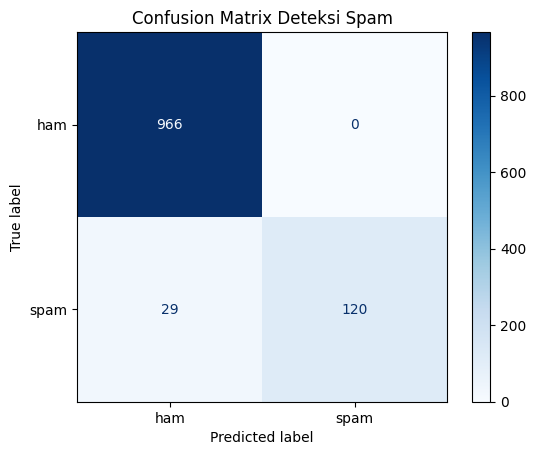

Ukuran data latih: 4457
Ukuran data uji: 1115


In [8]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred, labels=['ham', 'spam'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ham', 'spam'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix Deteksi Spam')
plt.show()

print('Ukuran data latih:', len(X_train))
print('Ukuran data uji:', len(X_test))

## 5. Prediksi pesan baru
Kebijakan berikut hanya simulasi: email sebaiknya tidak dihapus otomatis. Gunakan karantina, notifikasi, dan mekanisme pemulihan.

In [9]:
def prediksi_spam(teks):
    label = model.predict([teks])[0]
    kelas = list(model.classes_)
    probabilitas = model.predict_proba([teks])[0]
    p_spam = float(probabilitas[kelas.index('spam')])
    if p_spam >= 0.80:
        tindakan = 'karantina'
    elif p_spam >= 0.40:
        tindakan = 'tandai_mencurigakan'
    else:
        tindakan = 'inbox'
    return {
        'label_prediksi': label,
        'probabilitas_spam': round(p_spam, 4),
        'tindakan_simulasi': tindakan
    }

contoh_pesan = 'Congratulations! Claim your free prize now by clicking this link.'
prediksi_spam(contoh_pesan)

{'label_prediksi': np.str_('spam'),
 'probabilitas_spam': 0.9542,
 'tindakan_simulasi': 'karantina'}

## 6. Simpan model
Jangan unggah model ke repositori publik jika ia dibuat dari data yang sensitif.

In [12]:
joblib.dump(model, 'model_spam_baseline.joblib')
print('Model disimpan sebagai model_spam_baseline.joblib')

Model disimpan sebagai model_spam_baseline.joblib


In [13]:
from google.colab import files
files.download("model_spam_baseline.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>